# TP5 : Positionnement Multidimensionnel (MDS)

Importez les bibliothèques suivantes.

In [62]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA et la NMF. Le présent TP utilisant les résultats de ces dernier, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**), `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) et `NMF` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [63]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [64]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")

    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [65]:
""""from google.colab import files
data_to_load1 = files.upload()
import io
df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))"""

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va commencer par la définition progressive (par Monkey-Patching) d'une classe `MyMDS` implémentant l'algorithme de MDS donné dans la présentation.

In [66]:
class MyMDS:
    def __init__(self, n_components):
        self.n_components = n_components

        self.eigenvalues = None
        self.components = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

La première étape est de coder une fonction `distances(data)` construisant la matrice de distance d'une matrice de données `data`. Si $X$ est une matrice où chaque ligne est une donnée, la matrice $D$ de distances de $X$ est telles que $D_{ij} = d(X[i],X[j])$ pour tous $i,j$. Il serait par exemple possible d'utiliser la formule suivante :

- `np.linalg.norm(data.reshape((data.shape[0],1,data.shape[1])) - data.reshape((1,data.shape[0],data.shape[1]),axis=2)`

Néanmoins, si la matrice de données a 2535 lignes et 784 colonnes, la matrice intermédiaire utilisée dans ce calcul a $2535^2 \times 784$ entrées. Cela fait plus de 5 milliards. Cela rend le calcul infaisable (pour des raisons d'attribution de mémoire).

Pour cette raison, il convient d'utiliser la formule d'Al-Kashi :
$$d(x,y)^2 = ||x||^2 + ||y||^2 - 2 \langle x,y \rangle$$

(Note : Il se peut que des erreurs d'approximation résultent en de minuscules nombres négatifs au lieu de 0. Cela empêche l'utilisation de la fonction `np.sqrt`. Il convient alors de remplacer ces erreurs négatives par des 0.)

In [67]:
def distances(data):
    prodscalaire = data @ data.T
    normes = np.sum(data**2, axis=1)
    Dcarre = normes[:, None] + normes[None, :] - 2 * prodscalaire
    Dcarre[Dcarre < 0] = 0
    D = np.sqrt(Dcarre)

    return D


## Exercice 2

Il s'agit maintenant de construire les fonctions qui formeront le corps de la classe `MDS`.

1. Construisez une fonction `double_centre(D)` qui reconstruit la matrice de Gram à partir d'une matrice de distances.

In [68]:
def double_centre(D):
    n = D.shape[0]
    D2 = D**2
    J = np.eye(n) - (1/n) * np.ones((n, n))
    B = -0.5 * J @ D2 @ J

    return B



2. On opère ensuite une décomposition spectrale pour récupérer les valeurs propres et ses vecteurs propres de la matrice de Gram. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petite à la plus grande,
- `top_eigenvectors` est la matrice où chacune des $n$ colonnes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [69]:
def get_principal_components(comatrix, n_components):
    eigenvalues, eigenvectors = np.linalg.eigh(comatrix)
    top_eigenvalues = eigenvalues[-n_components:]
    top_eigenvectors = eigenvectors[:, -n_components:]


    return top_eigenvalues, top_eigenvectors


## Exercice 3

Nous allons maintenant construire la classe par Monkey-Patching.

1. Construisez une fonction `fit_transform(self, data)` implémentant la totalité de l'algorithme du MDS à l'aide des fonctions précedemments définies. Cette fonction renvoie la matrice projetée et assigne `self.eigenvalues` et `self.components` (au format où chaque ligne est une composante).

In [70]:
def fit_transform(self, data):
    D = distances(data)
    B = double_centre(D)
    self.eigenvalues, top_eigenvectors = get_principal_components( B, self.n_components)
    self.eigenvalues[self.eigenvalues<0]=0
    self.components = top_eigenvectors.T
    X_proj = top_eigenvectors @ np.diag(np.sqrt(self.eigenvalues))
    return X_proj


MyMDS.fit_transform=fit_transform



2. Vérifiez que la classe est bien implémentée en réalisant une MDS sur $X$ avec deux composantes. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**) coloré par nos labels (`y`). Faites la même chose avec une PCA à deux composantes. Les résultats devraient être les mêmes (à une rotation près).

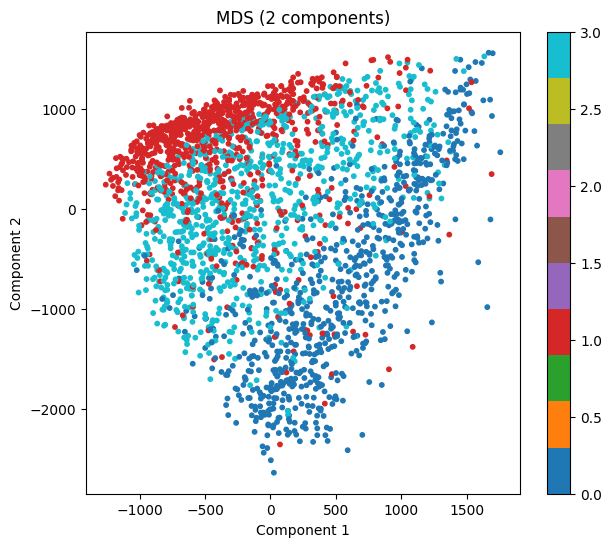

In [71]:
from sklearn.decomposition import PCA
mds = MyMDS(n_components=2)
X_mds = mds.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_mds[:,0], X_mds[:,1], c=y, cmap="tab10", s=10)
plt.title("MDS (2 components)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()


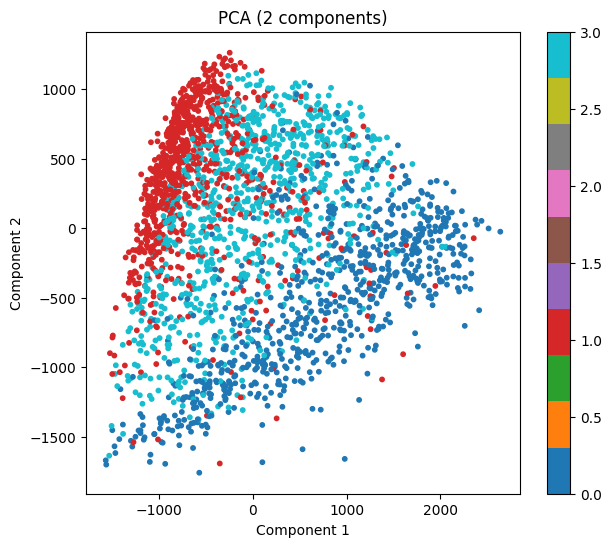

In [72]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=10)
plt.title("PCA (2 components)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()


## Exercice 4

Nous allons maintenant construire une classe `MyIsomap` implémentant l'algorithme Isomap présenté dans la présentation. Il va falloir faire une MDS sur une matrice de distances géodésiques approximées. Construisez la fonction `fit_transform(self, data)` qui retourne la matrice projetée après application de l'algorithme.

Utilisez la fonction `kneighbors_graph` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html)**) pour construire la matrice des distances des $k$ voisins les plus proches. Utilisez la fonction `shortest_path` (**[documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.shortest_path.html)**) pour implémenter l'algorithme de Djikstra.

In [73]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
import numpy as np

class MyIsomap:

    def __init__(self, n_neighbors, n_components):
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.mds = MyMDS(n_components)

    def fit_transform(self, X):
        kngraph = kneighbors_graph(X, n_neighbors=self.n_neighbors,mode="distance",include_self=False)


        geodesic_distances = shortest_path(kngraph, directed=False)

        B = double_centre(geodesic_distances)
        top_eigenvalues, top_eigenvectors = get_principal_components( B, self.n_components)
        X_proj = top_eigenvectors @ np.diag(np.sqrt(top_eigenvalues))

        return X_proj


## Exercice 5

1. Appliquez Isomap (deux composantes) à nos données et visualisez les résultats dans un nuage de points colorés par nos labels. Que se passe t-il lorsque l'on fait varier le nombre de voisins ?

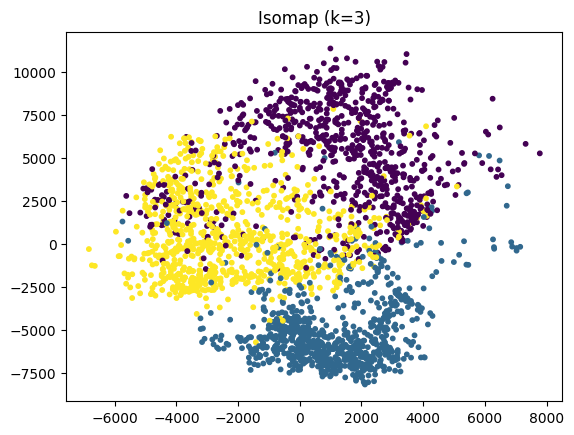

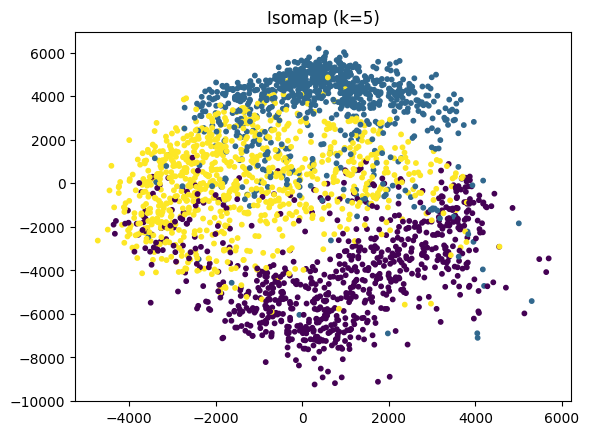

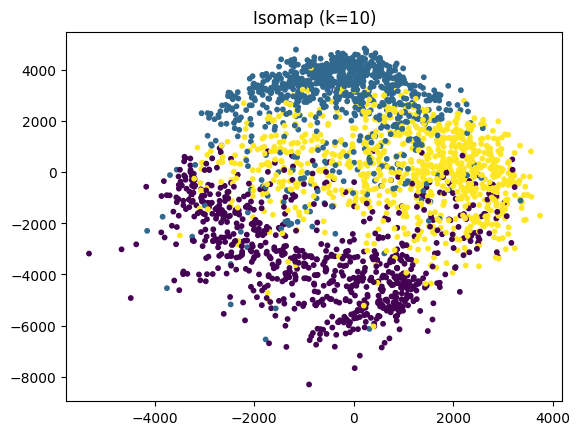

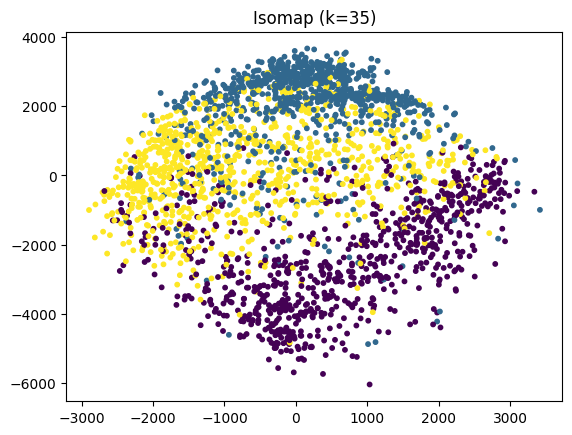

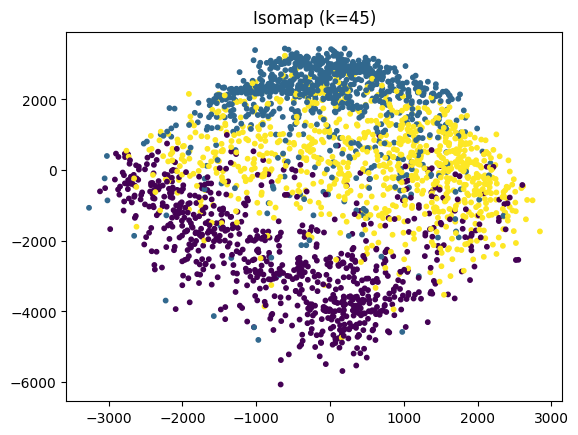

In [74]:

for k in [3, 5, 10, 35, 45]:

    iso = MyIsomap(n_neighbors=k, n_components=2)
    X_iso = iso.fit_transform(X)

    plt.scatter(X_iso[:,0], X_iso[:,1], c=y, s=10)
    plt.title(f"Isomap (k={k})")
    plt.show()



Quand on change le nombre de voisins dans Isomap, la forme du nuage change.
Quand le nombre de voisins est petit (par exemple 3), les groupes sont plus séparés. On voit mieux les différentes classes.
Quand on augmente le nombre de voisins (5, 10…), les groupes commencent à se rapprocher un peu.
Quand le nombre de voisins devient grand (35 ou 45), les points sont plus mélangés. La séparation entre les groupes est moins nette.
Donc plus on augmente le nombre de voisins, plus la projection sépare mal les données. Les meilleurs résultats sont obtenus avec un petit nombre de voisins.

2. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection Isomap de `X` en 2 dimensions, avec 3 clusters. Affichez la précision de ces labels. Pour quel nombre de voisins trouve t-on les meilleurs résultats ? Pourquoi ?

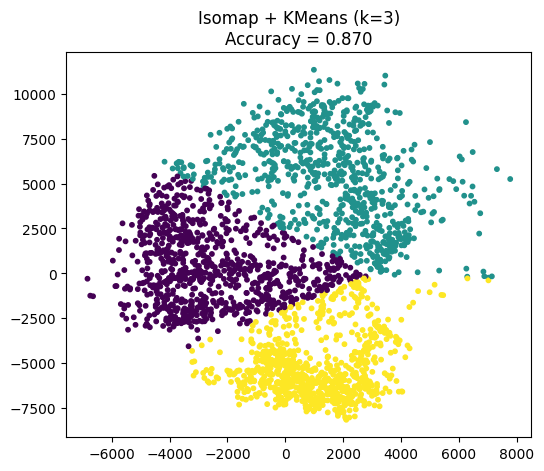

k_neighbors = 3 → Accuracy = 0.8698


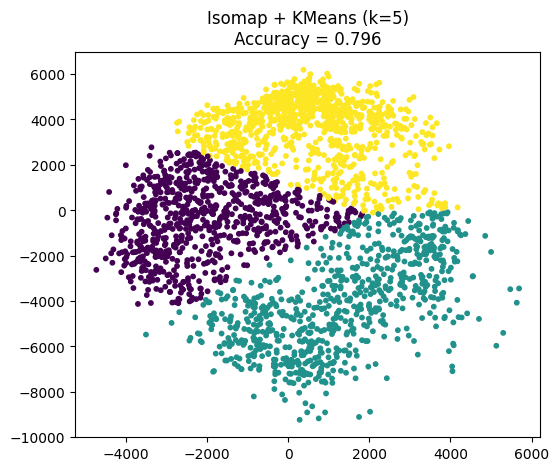

k_neighbors = 5 → Accuracy = 0.7957


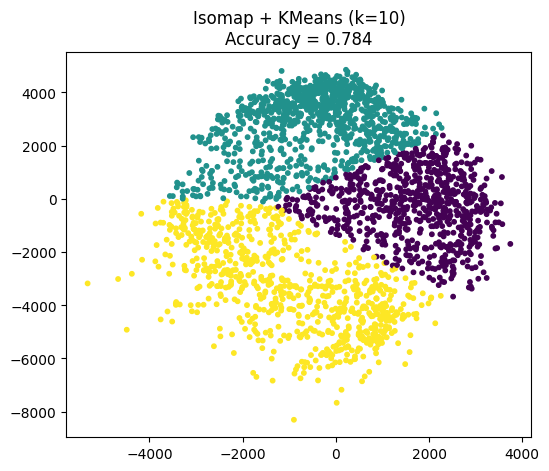

k_neighbors = 10 → Accuracy = 0.7842


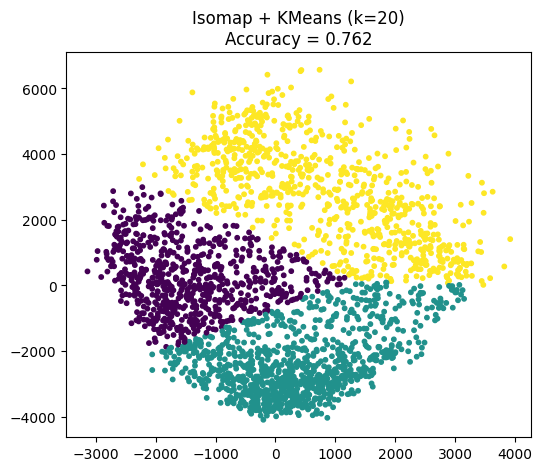

k_neighbors = 20 → Accuracy = 0.7621


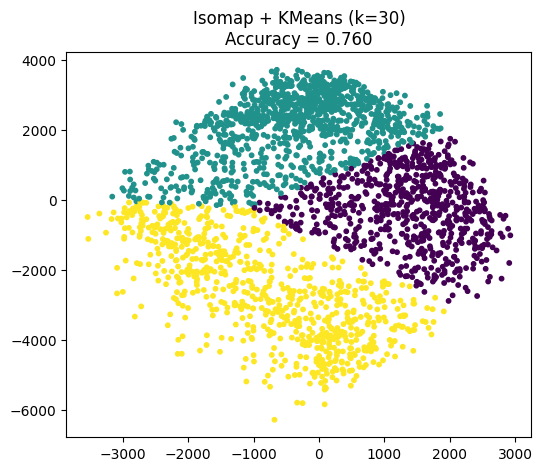

k_neighbors = 30 → Accuracy = 0.7598


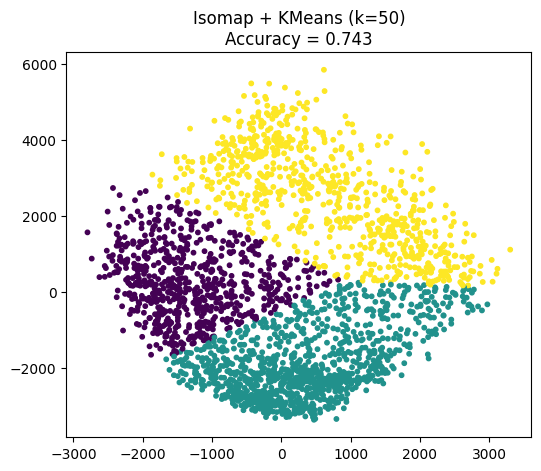

k_neighbors = 50 → Accuracy = 0.7432


In [75]:
from sklearn.cluster import KMeans

for k_neighbors in [3, 5, 10, 20, 30, 50]:


    iso = MyIsomap(n_neighbors=k_neighbors, n_components=2)
    X_iso = iso.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=0)
    labels = kmeans.fit_predict(X_iso)


    acc = accuracy(labels)

    plt.figure(figsize=(6,5))
    plt.scatter(X_iso[:,0], X_iso[:,1], c=labels, cmap="viridis", s=10)
    plt.title(f"Isomap + KMeans (k={k_neighbors})\nAccuracy = {acc:.3f}")
    plt.show()

    print(f"k_neighbors = {k_neighbors} → Accuracy = {acc:.4f}")



La meilleure précision est obtenue pour k = 3 voisins (accuracy environ 0,87). Ensuite, plus le nombre de voisins augmente, plus la précision diminue progressivement (jusqu’à environ 0,74 pour k = 50).

Cela signifie que lorsque le nombre de voisins est petit, Isomap conserve mieux la structure locale des données. Les distances géodésiques sont alors plus fidèles à la forme réelle des données, ce qui permet à KMeans de mieux séparer les groupes.

## Exercice 5

On peut utiliser Isomap pour mieux visualiser la manière dont la NMF peut séparer les données.

1. Réalisez une NMF sur $X$ avec 8 composantes. Utilisez la classe de `sklearn` avec la méthode d'initialisation `nndsvd` (pour de meilleurs résultats de convergence). Faites tourner un $3-$clustering sur la matrice projetée et affichez sa précision.

In [82]:
nmf = NMF(n_components=8,init="nndsvd",random_state=0, max_iter=500)

X_nmf = nmf.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=0)
labels_nmf = kmeans.fit_predict(X_nmf)
preci_nmf = accuracy(labels_nmf)
print(f"Accuracy (NMF + KMeans) = {preci_nmf:.2f}")

Accuracy (NMF + KMeans) = 0.87


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


2. Le résultat devrait être assez satisfaisant. Nous voulons maintenant visualisez la manière dont la séparation des données s'opére dans la NMF. Essayons d'abord de projeter en deux dimensions avec une méthode linéaire (PCA ou MDS). Visualisez le résultat avec un nuage de points colorés par nos labels `y`.

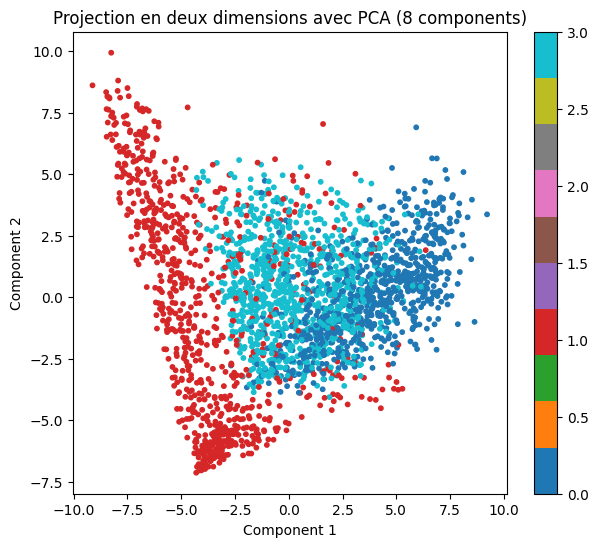

In [80]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_nmf_pca = pca.fit_transform(X_nmf)

plt.figure(figsize=(7,6))
plt.scatter(X_nmf_pca[:,0], X_nmf_pca[:,1], c=y, cmap="tab10", s=10)
plt.title("Projection en deux dimensions avec PCA (8 components)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()


3. Faites la même chose avec Isomap avec 10 voisins.

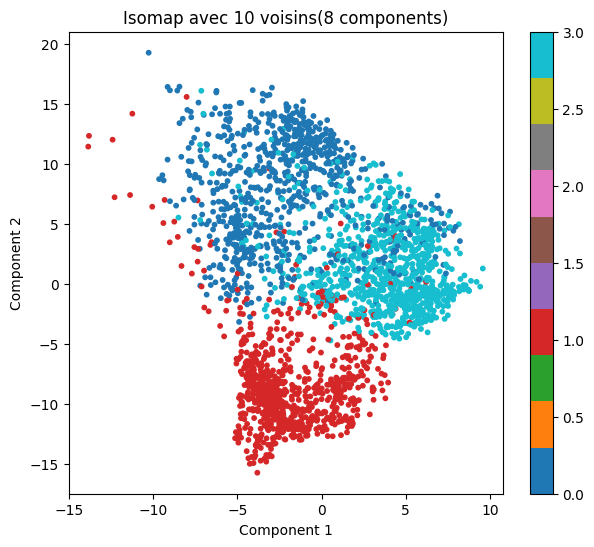

In [83]:

iso = MyIsomap(n_neighbors=10, n_components=2)

X_nmf_iso = iso.fit_transform(X_nmf)

plt.figure(figsize=(7,6))
plt.scatter(X_nmf_iso[:,0], X_nmf_iso[:,1], c=y, cmap="tab10", s=10)
plt.title("Isomap avec 10 voisins(8 components)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()


4. Faites varier le nombres de composantes de la NMF et le nombre de voisins dans l'Isomap. Interprétez les résultats.

In [79]:
for n_comp in [4, 8, 12, 20]:

    nmf = NMF(n_components=n_comp, init="nndsvd", random_state=0, max_iter=500)
    X_nmf = nmf.fit_transform(X)

    print(f"\n NMF components = {n_comp} :")

    for k_neighbors in [5, 10, 20]:

        iso = MyIsomap(n_neighbors=k_neighbors, n_components=2)
        X_iso = iso.fit_transform(X_nmf)

        kmeans = KMeans(n_clusters=3, random_state=0)
        labels = kmeans.fit_predict(X_iso)

        acc = accuracy(labels)

        print(f"k_neighbors = {k_neighbors} à une Accuracy de = {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(



 NMF components = 4 :
k_neighbors = 5 à une Accuracy de = 0.8659
k_neighbors = 10 à une Accuracy de = 0.8639
k_neighbors = 20 à une Accuracy de = 0.8572


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(



 NMF components = 8 :
k_neighbors = 5 à une Accuracy de = 0.8734
k_neighbors = 10 à une Accuracy de = 0.8682
k_neighbors = 20 à une Accuracy de = 0.8560


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(



 NMF components = 12 :
k_neighbors = 5 à une Accuracy de = 0.8903
k_neighbors = 10 à une Accuracy de = 0.8888
k_neighbors = 20 à une Accuracy de = 0.8757


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(



 NMF components = 20 :
k_neighbors = 5 à une Accuracy de = 0.8138
k_neighbors = 10 à une Accuracy de = 0.8387
k_neighbors = 20 à une Accuracy de = 0.8320


Les résultats montrent que le nombre de composantes de la NMF a une influence importante sur la qualité de la séparation. Avec 4 composantes, la représentation est correcte mais reste un peu simple, ce qui donne une accuracy autour de 0,86. Quand on passe à 8 puis 12 composantes, l’accuracy augmente progressivement jusqu’à environ 0,89 : cela signifie que la représentation en dimension plus élevée permet de mieux distinguer les groupes. En revanche, avec 20 composantes, l’accuracy baisse : la représentation devient plus difficile à projeter clairement en 2D et la séparation est moins nette. Concernant Isomap, on observe que 5 voisins donnent les meilleurs résultats. Si le nombre de voisins est trop petit, le graphe peut être moins stable, et si le nombre est trop grand, la méthode se rapproche d’un comportement plus linéaire et la séparation devient moins bonne. Globalement, les meilleurs résultats sont obtenus avec un nombre intermédiaire de composantes NMF et un nombre modéré de voisins dans Isomap ( 12 composantes et 5 voisins).